# GNN Analysis for AI Lab Gene Expression Data

In this notebook, I try Graph Neural Networks on the AI Lab gene expression data.

I test two graph ideas:

1. **Cell graph GNN**
   - each node is one cell/sample
   - node features are gene expression values
   - edges connect similar cells
   - task: predict hypoxia vs normoxia

2. **Gene graph GNN**
   - each node is one gene
   - edges connect genes with similar expression patterns
   - task: predict whether a gene looks more hypoxia-associated or normoxia-associated

I use both:
- GCN
- GraphSAGE

I also include visual graph plots, training curves, accuracy, F1 score, and confusion matrices.

## 1. Install packages if needed

Run this only if something is missing.

`torch-geometric` can sometimes be difficult on Windows or with new GPUs.  
If GPU causes issues, this notebook can still run on CPU.

In [2]:
# %pip install torch numpy pandas matplotlib seaborn scikit-learn networkx umap-learn
# %pip install torch-geometric

## 2. Imports

Here I import the tools for data loading, graphs, GNN models, and evaluation.

In [3]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import torch
from torch import nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, SAGEConv
    from torch_geometric.utils import to_networkx
    TORCH_GEOMETRIC_AVAILABLE = True
except Exception as e:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("torch-geometric could not be imported.")
    print("Error:", e)

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
print("torch-geometric available:", TORCH_GEOMETRIC_AVAILABLE)

Using device: cuda
torch-geometric available: True


## 3. Set the paths

Change `BASE` to your own local data folder.

In [4]:
BASE = Path(r"C:\Users\hugoo\OneDrive\Desktop\ai-lab-report\data")

SMART = BASE / "SmartSeq"
DROP = BASE / "DropSeq"

OUTPUT = BASE.parent / "gnn_outputs"
OUTPUT.mkdir(exist_ok=True)

print("SmartSeq exists:", SMART.exists())
print("DropSeq exists:", DROP.exists())
print("Output folder:", OUTPUT)

SmartSeq exists: True
DropSeq exists: True
Output folder: C:\Users\hugoo\OneDrive\Desktop\ai-lab-report\gnn_outputs


## 4. Helper functions for loading the data

These functions load expression files and create simple binary labels.

For this notebook:
- hypoxia = 1
- normoxia = 0

In [5]:
def load_expr(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    return df

def get_dropseq_condition(sample_name):
    if "Normoxia" in sample_name:
        return "Normoxia"
    if "Hypoxia" in sample_name:
        return "Hypoxia"
    return "Unknown"

def make_binary_labels(labels):
    return labels.astype(str).str.contains("Hyp", case=False, na=False).astype(int)

def prepare_xy(expr, labels):
    X = expr.T.copy()
    y = make_binary_labels(labels.loc[X.index])
    return X, y

## 5. Load the normalized training data

I use the normalized 3000-gene training files because they are already cleaner and better for machine learning.

In [6]:
smart_mcf7 = load_expr(SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt")
smart_hcc = load_expr(SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt")

drop_mcf7 = load_expr(DROP / "MCF7_Filtered_Normalised_3000_Data_train.txt")
drop_hcc = load_expr(DROP / "HCC1806_Filtered_Normalised_3000_Data_train.txt")

meta_mcf7 = pd.read_csv(SMART / "MCF7_SmartS_MetaData.tsv", sep="\t")
meta_hcc = pd.read_csv(SMART / "HCC1806_SmartS_MetaData.tsv", sep="\t")

meta_mcf7["Filename"] = meta_mcf7["Filename"].astype(str).str.replace('"', '', regex=False)
meta_hcc["Filename"] = meta_hcc["Filename"].astype(str).str.replace('"', '', regex=False)

smart_mcf7_labels = meta_mcf7.set_index("Filename").loc[smart_mcf7.columns, "Condition"]
smart_hcc_labels = meta_hcc.set_index("Filename").loc[smart_hcc.columns, "Condition"]

drop_mcf7_labels = pd.Series([get_dropseq_condition(c) for c in drop_mcf7.columns], index=drop_mcf7.columns)
drop_hcc_labels = pd.Series([get_dropseq_condition(c) for c in drop_hcc.columns], index=drop_hcc.columns)

datasets = {
    "SmartSeq_MCF7": (smart_mcf7, smart_mcf7_labels),
    "SmartSeq_HCC1806": (smart_hcc, smart_hcc_labels),
    "DropSeq_MCF7": (drop_mcf7, drop_mcf7_labels),
    "DropSeq_HCC1806": (drop_hcc, drop_hcc_labels),
}

for name, (expr, labels) in datasets.items():
    print(name, expr.shape, labels.value_counts().to_dict())

SmartSeq_MCF7 (3000, 250) {'Norm': 126, 'Hypo': 124}
SmartSeq_HCC1806 (3000, 182) {'Hypo': 97, 'Normo': 85}
DropSeq_MCF7 (3000, 21626) {'Normoxia': 12705, 'Hypoxia': 8921}
DropSeq_HCC1806 (3000, 14682) {'Hypoxia': 8899, 'Normoxia': 5783}


## 6. Choose the dataset

I can change this variable to run the same GNN workflow on another dataset.

In [7]:
DATASET_NAME = "SmartSeq_MCF7"

expr, labels = datasets[DATASET_NAME]
print("Selected dataset:", DATASET_NAME)
print("Expression shape:", expr.shape)
print(labels.value_counts())

Selected dataset: SmartSeq_MCF7
Expression shape: (3000, 250)
Condition
Norm    126
Hypo    124
Name: count, dtype: int64


# Part A: Cell Graph GNN

In this part, I build a graph where each node is a cell/sample.

The logic is:
- similar cells are connected
- each cell has its 3000 gene expression values as features
- the GNN predicts the condition of each cell

## 7. Build a cell graph

I connect each cell to its nearest neighbors based on expression similarity.

In [8]:
def build_cell_graph(expr, labels, k=10):
    X, y = prepare_xy(expr, labels)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    adjacency = kneighbors_graph(
        X_scaled,
        n_neighbors=k,
        mode="connectivity",
        include_self=False
    )
    adjacency = adjacency.maximum(adjacency.T)

    edge_index_np = np.vstack(adjacency.nonzero())

    data = Data(
        x=torch.tensor(X_scaled, dtype=torch.float32),
        edge_index=torch.tensor(edge_index_np, dtype=torch.long),
        y=torch.tensor(y.values, dtype=torch.long)
    )

    data.sample_names = list(X.index)
    data.gene_names = list(X.columns)

    return data, X, y, adjacency

cell_data, cell_X, cell_y, cell_adj = build_cell_graph(expr, labels, k=10)

print(cell_data)
print("Number of nodes:", cell_data.num_nodes)
print("Number of edges:", cell_data.num_edges)
print("Number of node features:", cell_data.num_features)

Data(x=[250, 3000], edge_index=[2, 4690], y=[250], sample_names=[250], gene_names=[3000])
Number of nodes: 250
Number of edges: 4690
Number of node features: 3000


## 8. Create train/validation/test masks

For GNNs, I split the nodes into training, validation, and test nodes.

In [9]:
def add_node_masks(data, y, train_size=0.7, val_size=0.15):
    indices = np.arange(data.num_nodes)

    train_idx, temp_idx = train_test_split(
        indices,
        train_size=train_size,
        random_state=SEED,
        stratify=y
    )

    val_relative = val_size / (1 - train_size)

    val_idx, test_idx = train_test_split(
        temp_idx,
        train_size=val_relative,
        random_state=SEED,
        stratify=y.iloc[temp_idx]
    )

    data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True

    data.train_idx = train_idx
    data.val_idx = val_idx
    data.test_idx = test_idx

    return data

cell_data = add_node_masks(cell_data, cell_y)
cell_data = cell_data.to(DEVICE)

print("Train nodes:", int(cell_data.train_mask.sum()))
print("Val nodes:", int(cell_data.val_mask.sum()))
print("Test nodes:", int(cell_data.test_mask.sum()))

Train nodes: 175
Val nodes: 37
Test nodes: 38


In [10]:
train_idx = cell_data.train_idx
val_idx = cell_data.val_idx
test_idx = cell_data.test_idx

scaler = StandardScaler()

X_scaled = np.zeros_like(cell_X.values, dtype=np.float32)

X_scaled[train_idx] = scaler.fit_transform(cell_X.iloc[train_idx])
X_scaled[val_idx] = scaler.transform(cell_X.iloc[val_idx])
X_scaled[test_idx] = scaler.transform(cell_X.iloc[test_idx])

cell_data.x = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)

print("Scaler refit only on training nodes.")
print("Feature matrix shape:", cell_data.x.shape)
print("Device:", cell_data.x.device)

Scaler refit only on training nodes.
Feature matrix shape: torch.Size([250, 3000])
Device: cuda:0


## 9. Visualize the cell graph

I plot a smaller version of the graph so it is easier to see.

The colors show:
- 0 = normoxia
- 1 = hypoxia

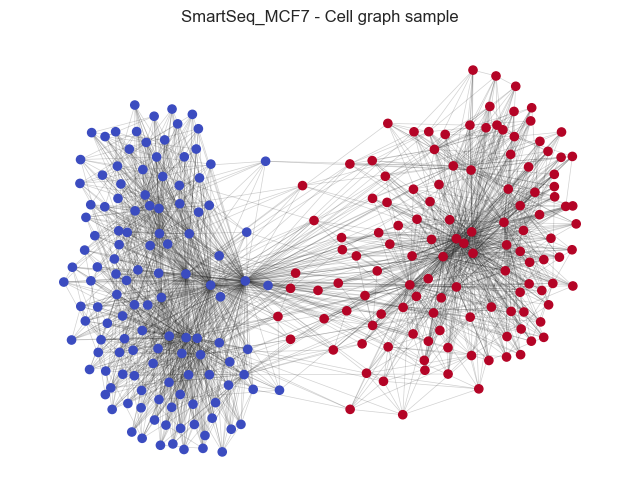

In [11]:
def plot_graph_sample(data, title, max_nodes=250):
    data_cpu = data.cpu()

    if data_cpu.num_nodes > max_nodes:
        selected = np.random.choice(data_cpu.num_nodes, max_nodes, replace=False)
        selected_set = set(selected)
        edge_index = data_cpu.edge_index.numpy()
        keep_edges = [
            i for i in range(edge_index.shape[1])
            if edge_index[0, i] in selected_set and edge_index[1, i] in selected_set
        ]
        G = nx.Graph()
        G.add_nodes_from(selected)
        for i in keep_edges:
            G.add_edge(edge_index[0, i], edge_index[1, i])
        node_colors = [int(data_cpu.y[n]) for n in G.nodes()]
    else:
        G = to_networkx(data_cpu, to_undirected=True)
        node_colors = [int(data_cpu.y[n]) for n in G.nodes()]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=SEED)
    nx.draw_networkx_nodes(G, pos, node_size=35, node_color=node_colors, cmap="coolwarm")
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_graph_sample(cell_data, f"{DATASET_NAME} - Cell graph sample")

## 10. Define GCN and GraphSAGE

GCN and GraphSAGE both use neighbors in the graph.

- GCN is the simpler baseline.
- GraphSAGE is a bit more flexible and often works well on bigger graphs.

In [12]:
class GCNNodeClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.out(x, edge_index)
        return x

class GraphSAGENodeClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.out = SAGEConv(hidden_dim, output_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.out(x, edge_index)
        return x

## 11. Training and evaluation functions

These functions train the GNN and calculate accuracy/F1.

In [13]:
def train_gnn_node_classifier(model, data, epochs=150, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    data = data.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            pred = logits.argmax(dim=1)

            train_acc = accuracy_score(
                data.y[data.train_mask].cpu().numpy(),
                pred[data.train_mask].cpu().numpy()
            )
            val_acc = accuracy_score(
                data.y[data.val_mask].cpu().numpy(),
                pred[data.val_mask].cpu().numpy()
            )
            val_f1 = f1_score(
                data.y[data.val_mask].cpu().numpy(),
                pred[data.val_mask].cpu().numpy()
            )

        history.append({
            "epoch": epoch,
            "loss": float(loss.item()),
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "val_f1": val_f1
        })

        if epoch == 1 or epoch % 25 == 0:
            print(
                f"Epoch {epoch:03d} | loss {loss.item():.4f} | "
                f"train acc {train_acc:.3f} | val acc {val_acc:.3f}"
            )

    return pd.DataFrame(history)

def evaluate_gnn_node_classifier(model, data, split="test"):
    model = model.to(DEVICE)
    data = data.to(DEVICE)

    model.eval()
    mask = getattr(data, f"{split}_mask")

    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        pred = logits.argmax(dim=1)

    y_true = data.y[mask].cpu().numpy()
    y_pred = pred[mask].cpu().numpy()

    print(classification_report(y_true, y_pred, target_names=["Normoxia", "Hypoxia"]))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }, pd.DataFrame({"true": y_true, "pred": y_pred})

## 12. Train GCN on the cell graph

In [14]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gcn_cell = GCNNodeClassifier(
    input_dim=cell_data.num_features,
    hidden_dim=64,
    output_dim=2
).to(DEVICE)

cell_data = cell_data.to(DEVICE)

gcn_cell_history = train_gnn_node_classifier(gcn_cell, cell_data, epochs=150)
gcn_cell_metrics, gcn_cell_preds = evaluate_gnn_node_classifier(
    gcn_cell, cell_data, split="test"
)

Epoch 001 | loss 0.8076 | train acc 0.503 | val acc 0.514
Epoch 025 | loss 0.0221 | train acc 0.994 | val acc 1.000
Epoch 050 | loss 0.0089 | train acc 1.000 | val acc 1.000
Epoch 075 | loss 0.0132 | train acc 1.000 | val acc 1.000
Epoch 100 | loss 0.0062 | train acc 1.000 | val acc 1.000
Epoch 125 | loss 0.0039 | train acc 1.000 | val acc 1.000
Epoch 150 | loss 0.0034 | train acc 1.000 | val acc 1.000
              precision    recall  f1-score   support

    Normoxia       1.00      1.00      1.00        19
     Hypoxia       1.00      1.00      1.00        19

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Confusion matrix:
[[19  0]
 [ 0 19]]


## 13. Train GraphSAGE on the cell graph

In [15]:
sage_cell = GraphSAGENodeClassifier(input_dim=cell_data.num_features, hidden_dim=64, output_dim=2)
sage_cell_history = train_gnn_node_classifier(sage_cell, cell_data, epochs=150)
sage_cell_metrics, sage_cell_preds = evaluate_gnn_node_classifier(sage_cell, cell_data, split="test")

sage_cell_history.to_csv(OUTPUT / f"{DATASET_NAME}_cell_graphsage_history.csv", index=False)
sage_cell_preds.to_csv(OUTPUT / f"{DATASET_NAME}_cell_graphsage_predictions.csv", index=False)

sage_cell_metrics

Epoch 001 | loss 0.7168 | train acc 0.994 | val acc 1.000
Epoch 025 | loss 0.0015 | train acc 1.000 | val acc 1.000
Epoch 050 | loss 0.0002 | train acc 1.000 | val acc 1.000
Epoch 075 | loss 0.0000 | train acc 1.000 | val acc 1.000
Epoch 100 | loss 0.0001 | train acc 1.000 | val acc 1.000
Epoch 125 | loss 0.0001 | train acc 1.000 | val acc 1.000
Epoch 150 | loss 0.0002 | train acc 1.000 | val acc 1.000
              precision    recall  f1-score   support

    Normoxia       1.00      1.00      1.00        19
     Hypoxia       1.00      1.00      1.00        19

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Confusion matrix:
[[19  0]
 [ 0 19]]


{'accuracy': 1.0, 'f1': 1.0}

## 14. Plot cell GNN training curves

This helps me see if the models are learning normally.

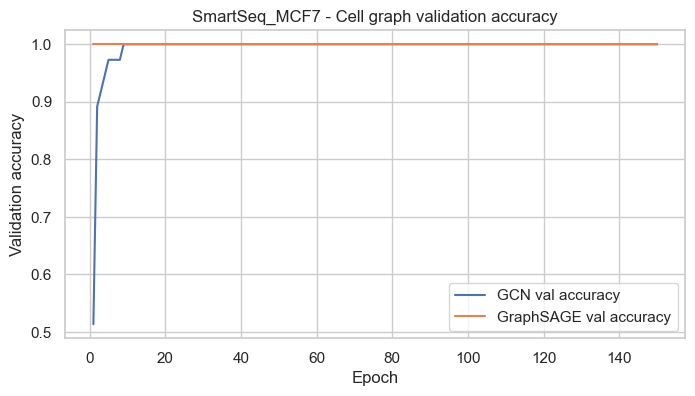

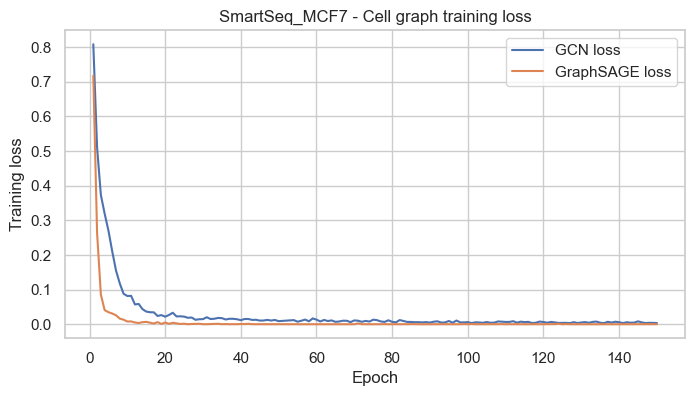

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(gcn_cell_history["epoch"], gcn_cell_history["val_accuracy"], label="GCN val accuracy")
plt.plot(sage_cell_history["epoch"], sage_cell_history["val_accuracy"], label="GraphSAGE val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(f"{DATASET_NAME} - Cell graph validation accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(gcn_cell_history["epoch"], gcn_cell_history["loss"], label="GCN loss")
plt.plot(sage_cell_history["epoch"], sage_cell_history["loss"], label="GraphSAGE loss")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title(f"{DATASET_NAME} - Cell graph training loss")
plt.legend()
plt.show()

## 15. Cell GNN comparison

In [17]:
cell_gnn_comparison = pd.DataFrame([
    {"graph": "cell_graph", "model": "GCN", **gcn_cell_metrics},
    {"graph": "cell_graph", "model": "GraphSAGE", **sage_cell_metrics},
])

cell_gnn_comparison.to_csv(OUTPUT / f"{DATASET_NAME}_cell_gnn_comparison.csv", index=False)
cell_gnn_comparison

,graph,model,accuracy,f1
0,cell_graph,GCN,1.0,1.0
1,cell_graph,GraphSAGE,1.0,1.0


# Part B: Gene Graph GNN

Now I build a graph where each node is a gene.

This is more experimental because the gene labels are created from the data itself.

The graph is based on gene-gene expression similarity, not a known pathway database.

## 16. Create simple gene labels

I label a gene as:

- 1 if its average expression is higher in hypoxia
- 0 if its average expression is higher in normoxia

This is simple and useful for exploration, but it is not a formal differential expression test.

In [18]:
def make_gene_labels(expr, labels):
    condition = labels.loc[expr.columns]
    hyp_cols = condition[condition.astype(str).str.contains("Hyp", case=False, na=False)].index
    norm_cols = condition[condition.astype(str).str.contains("Norm", case=False, na=False)].index

    hyp_mean = expr[hyp_cols].mean(axis=1)
    norm_mean = expr[norm_cols].mean(axis=1)
    gene_label = (hyp_mean > norm_mean).astype(int)

    diff_df = pd.DataFrame({
        "mean_hypoxia": hyp_mean,
        "mean_normoxia": norm_mean,
        "diff": hyp_mean - norm_mean,
        "gene_label": gene_label
    })
    return gene_label, diff_df

gene_labels, gene_diff_df = make_gene_labels(expr, labels)
print(gene_labels.value_counts())
display(gene_diff_df.head())

0    1509
1    1491
Name: count, dtype: int64


,mean_hypoxia,mean_normoxia,diff,gene_label
CYP1B1,10696.193548,296.079365,10400.114183,1
CYP1B1-AS1,4430.491935,121.126984,4309.364951,1
CYP1A1,3233.911290,1.111111,3232.800179,1
NDRG1,1203.637097,18.603175,1185.033922,1
DDIT4,4663.588710,344.960317,4318.628392,1


## 17. Build the gene graph

Each node is a gene.

Each gene's features are its expression values across cells.  
I connect genes with similar expression patterns.

In [19]:
def build_gene_graph(expr, labels, k=10, max_genes=1000):
    gene_label, diff_df = make_gene_labels(expr, labels)

    # I keep only the most variable genes so the graph stays manageable.
    if expr.shape[0] > max_genes:
        selected_genes = expr.var(axis=1).sort_values(ascending=False).head(max_genes).index
        expr_sub = expr.loc[selected_genes]
        gene_label = gene_label.loc[selected_genes]
        diff_df = diff_df.loc[selected_genes]
    else:
        expr_sub = expr.copy()

    X = expr_sub.copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    adjacency = kneighbors_graph(
        X_scaled,
        n_neighbors=k,
        mode="connectivity",
        include_self=False
    )
    adjacency = adjacency.maximum(adjacency.T)

    edge_index_np = np.vstack(adjacency.nonzero())

    data = Data(
        x=torch.tensor(X_scaled, dtype=torch.float32),
        edge_index=torch.tensor(edge_index_np, dtype=torch.long),
        y=torch.tensor(gene_label.values, dtype=torch.long)
    )
    data.gene_names = list(expr_sub.index)

    return data, expr_sub, gene_label, diff_df, adjacency

gene_data, gene_expr_sub, gene_y, gene_diff_sub, gene_adj = build_gene_graph(expr, labels, k=10, max_genes=1000)

print(gene_data)
print("Number of gene nodes:", gene_data.num_nodes)
print("Number of edges:", gene_data.num_edges)
print("Number of features per gene:", gene_data.num_features)

Data(x=[1000, 250], edge_index=[2, 18578], y=[1000], gene_names=[1000])
Number of gene nodes: 1000
Number of edges: 18578
Number of features per gene: 250


## 18. Create masks for gene nodes

In [20]:
gene_data = add_node_masks(gene_data, gene_y)
gene_data = gene_data.to(DEVICE)

print("Train gene nodes:", int(gene_data.train_mask.sum()))
print("Val gene nodes:", int(gene_data.val_mask.sum()))
print("Test gene nodes:", int(gene_data.test_mask.sum()))

Train gene nodes: 700
Val gene nodes: 149
Test gene nodes: 151


## 19. Visualize the gene graph

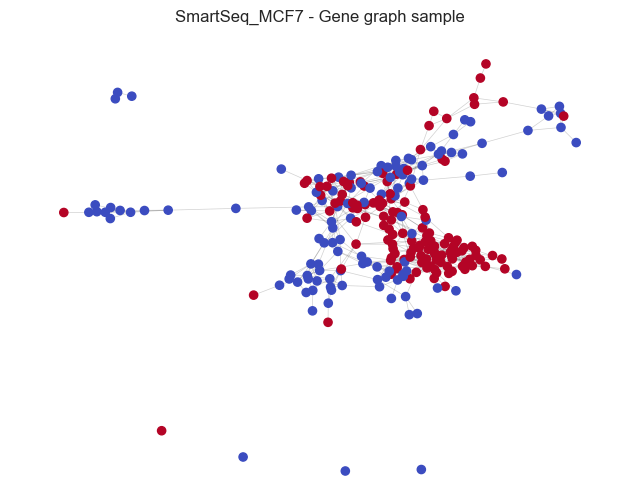

In [21]:
plot_graph_sample(gene_data, f"{DATASET_NAME} - Gene graph sample", max_nodes=250)

## 20. Train GCN on the gene graph

In [22]:
gcn_gene = GCNNodeClassifier(input_dim=gene_data.num_features, hidden_dim=64, output_dim=2)
gcn_gene_history = train_gnn_node_classifier(gcn_gene, gene_data, epochs=150)
gcn_gene_metrics, gcn_gene_preds = evaluate_gnn_node_classifier(gcn_gene, gene_data, split="test")

gcn_gene_history.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gcn_history.csv", index=False)
gcn_gene_preds.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gcn_predictions.csv", index=False)

gcn_gene_metrics

Epoch 001 | loss 0.7082 | train acc 0.787 | val acc 0.785
Epoch 025 | loss 0.3138 | train acc 0.879 | val acc 0.899
Epoch 050 | loss 0.2311 | train acc 0.909 | val acc 0.899
Epoch 075 | loss 0.2126 | train acc 0.917 | val acc 0.913
Epoch 100 | loss 0.1972 | train acc 0.916 | val acc 0.913
Epoch 125 | loss 0.1885 | train acc 0.917 | val acc 0.919
Epoch 150 | loss 0.1780 | train acc 0.924 | val acc 0.933
              precision    recall  f1-score   support

    Normoxia       0.90      0.96      0.93        73
     Hypoxia       0.96      0.90      0.93        78

    accuracy                           0.93       151
   macro avg       0.93      0.93      0.93       151
weighted avg       0.93      0.93      0.93       151

Confusion matrix:
[[70  3]
 [ 8 70]]


{'accuracy': 0.9271523178807947, 'f1': 0.9271523178807947}

## 21. Train GraphSAGE on the gene graph

In [23]:
sage_gene = GraphSAGENodeClassifier(input_dim=gene_data.num_features, hidden_dim=64, output_dim=2)
sage_gene_history = train_gnn_node_classifier(sage_gene, gene_data, epochs=150)
sage_gene_metrics, sage_gene_preds = evaluate_gnn_node_classifier(sage_gene, gene_data, split="test")

sage_gene_history.to_csv(OUTPUT / f"{DATASET_NAME}_gene_graphsage_history.csv", index=False)
sage_gene_preds.to_csv(OUTPUT / f"{DATASET_NAME}_gene_graphsage_predictions.csv", index=False)

sage_gene_metrics

Epoch 001 | loss 0.7118 | train acc 0.531 | val acc 0.537
Epoch 025 | loss 0.2330 | train acc 0.904 | val acc 0.919
Epoch 050 | loss 0.1754 | train acc 0.933 | val acc 0.926
Epoch 075 | loss 0.1318 | train acc 0.946 | val acc 0.940
Epoch 100 | loss 0.1027 | train acc 0.954 | val acc 0.946
Epoch 125 | loss 0.0871 | train acc 0.980 | val acc 0.966
Epoch 150 | loss 0.0450 | train acc 0.989 | val acc 0.973
              precision    recall  f1-score   support

    Normoxia       0.94      0.99      0.96        73
     Hypoxia       0.99      0.94      0.96        78

    accuracy                           0.96       151
   macro avg       0.96      0.96      0.96       151
weighted avg       0.96      0.96      0.96       151

Confusion matrix:
[[72  1]
 [ 5 73]]


{'accuracy': 0.9602649006622517, 'f1': 0.9605263157894737}

## 22. Plot gene GNN training curves

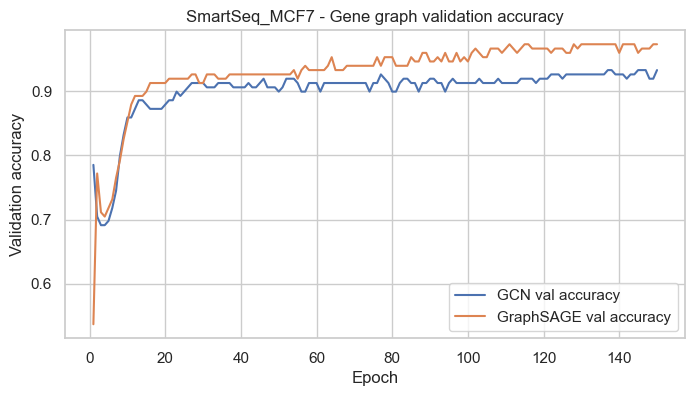

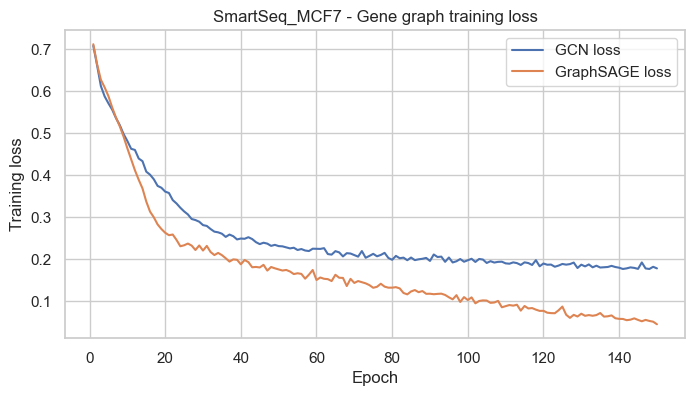

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(gcn_gene_history["epoch"], gcn_gene_history["val_accuracy"], label="GCN val accuracy")
plt.plot(sage_gene_history["epoch"], sage_gene_history["val_accuracy"], label="GraphSAGE val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title(f"{DATASET_NAME} - Gene graph validation accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(gcn_gene_history["epoch"], gcn_gene_history["loss"], label="GCN loss")
plt.plot(sage_gene_history["epoch"], sage_gene_history["loss"], label="GraphSAGE loss")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title(f"{DATASET_NAME} - Gene graph training loss")
plt.legend()
plt.show()

## 23. Gene GNN comparison

In [25]:
gene_gnn_comparison = pd.DataFrame([
    {"graph": "gene_graph", "model": "GCN", **gcn_gene_metrics},
    {"graph": "gene_graph", "model": "GraphSAGE", **sage_gene_metrics},
])

gene_gnn_comparison.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gnn_comparison.csv", index=False)
gene_gnn_comparison

,graph,model,accuracy,f1
0,gene_graph,GCN,0.927152,0.927152
1,gene_graph,GraphSAGE,0.960265,0.960526


## 24. Combined GNN results

In [26]:
all_gnn_results = pd.concat([cell_gnn_comparison, gene_gnn_comparison], ignore_index=True)
all_gnn_results.to_csv(OUTPUT / f"{DATASET_NAME}_all_gnn_results.csv", index=False)
all_gnn_results

,graph,model,accuracy,f1
0,cell_graph,GCN,1.000000,1.000000
1,cell_graph,GraphSAGE,1.000000,1.000000
2,gene_graph,GCN,0.927152,0.927152
3,gene_graph,GraphSAGE,0.960265,0.960526


## 25. Bar plots for GNN results

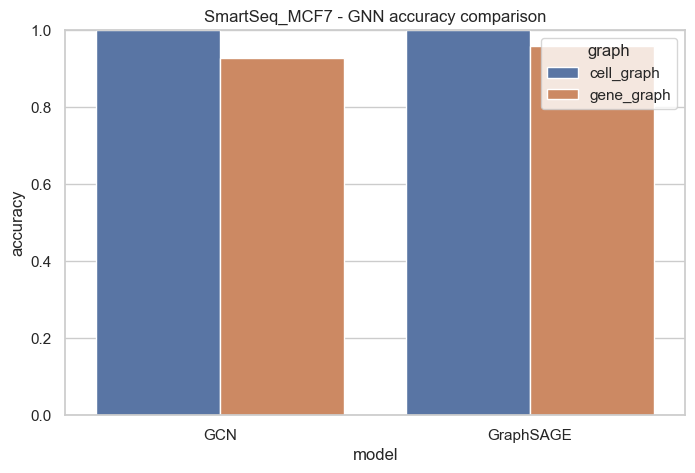

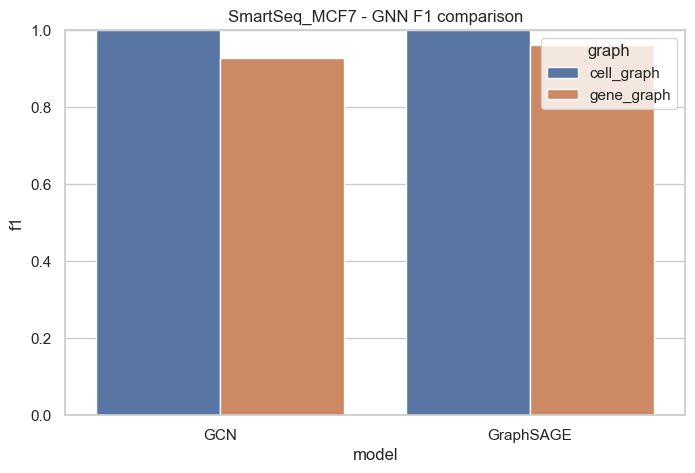

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=all_gnn_results, x="model", y="accuracy", hue="graph")
plt.ylim(0, 1)
plt.title(f"{DATASET_NAME} - GNN accuracy comparison")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=all_gnn_results, x="model", y="f1", hue="graph")
plt.ylim(0, 1)
plt.title(f"{DATASET_NAME} - GNN F1 comparison")
plt.show()

## 26. Visualize GNN embeddings

Here I extract hidden embeddings from the GCN and plot them with PCA.

This helps me see whether the GNN learned a useful structure.

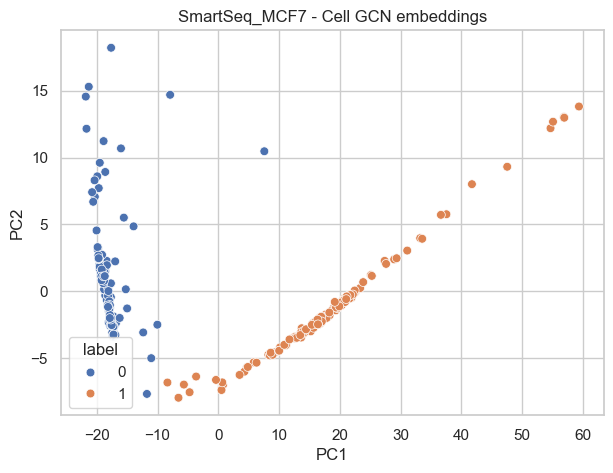

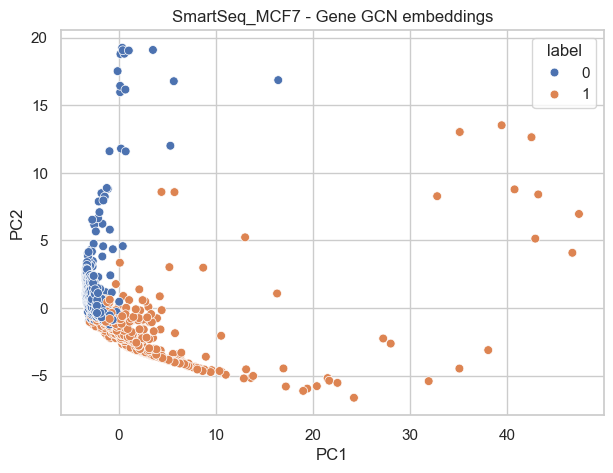

In [28]:
class GCNEmbeddingExtractor(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.trained_model = trained_model

    def get_embedding(self, x, edge_index):
        model = self.trained_model
        model.eval()
        with torch.no_grad():
            x = model.conv1(x, edge_index)
            x = F.relu(x)
            x = model.conv2(x, edge_index)
            x = F.relu(x)
        return x

def plot_gnn_embeddings(model, data, title):
    emb_model = GCNEmbeddingExtractor(model)
    emb = emb_model.get_embedding(data.x, data.edge_index).detach().cpu().numpy()

    pcs = PCA(n_components=2, random_state=SEED).fit_transform(emb)

    plot_df = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        "label": data.y.detach().cpu().numpy()
    })

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="label", s=40)
    plt.title(title)
    plt.show()

    return plot_df

cell_embedding_df = plot_gnn_embeddings(gcn_cell, cell_data, f"{DATASET_NAME} - Cell GCN embeddings")
gene_embedding_df = plot_gnn_embeddings(gcn_gene, gene_data, f"{DATASET_NAME} - Gene GCN embeddings")

cell_embedding_df.to_csv(OUTPUT / f"{DATASET_NAME}_cell_gcn_embeddings.csv", index=False)
gene_embedding_df.to_csv(OUTPUT / f"{DATASET_NAME}_gene_gcn_embeddings.csv", index=False)

## GNN Results and Discussion

The cell graph achieved perfect performance for both GCN and GraphSAGE, reaching an accuracy and F1 score of 1.00 on the test set. Initially, I found these results somewhat suspicious because perfect classification is uncommon in most machine learning problems. However, after examining the PCA projection, graph visualizations, confusion matrices, and training curves, the results appear reasonable for this dataset.

The visualizations show a strong separation between normoxia and hypoxia cells, suggesting that the biological signal is highly informative. The confusion matrices further confirm this observation, as all test samples were classified correctly by both models. Even after correcting the feature scaling procedure to avoid fitting the scaler on the full dataset, the results remained unchanged, indicating that the high performance is likely due to the strong separability of the two conditions rather than preprocessing issues.

The gene graph produced slightly lower but still very strong results. GCN achieved approximately 93% accuracy and F1 score, while GraphSAGE achieved approximately 96%. Unlike the cell graph, where each node directly represents a cell with its full expression profile, the gene graph requires the model to learn relationships between genes and infer the biological condition indirectly. This makes the classification task more challenging and explains the lower performance.

Comparing the two architectures, GraphSAGE consistently performed at least as well as GCN and achieved the best results on the gene graph. This suggests that GraphSAGE was better able to capture information from neighboring nodes and learn meaningful representations from the graph structure.

Overall, the results indicate that hypoxia and normoxia are highly distinguishable in this dataset. The cell graph provides near-perfect separation between conditions, while the gene graph presents a more challenging and arguably more realistic classification task. Despite the increased difficulty, both GNN architectures achieved strong predictive performance, with GraphSAGE emerging as the best-performing model overall.

# Professor Extension for the GNN notebook: graph explainability and biological interpretation

This section connects the GNN analysis to the professor's requested biological interpretation. The attached `DataInterpretation_resources.pdf` recommends pathway/signature interpretation of important predictive genes, especially hypoxia/HIF resources such as Hallmark Hypoxia, Buffa/Winter/Ragnum metagenes, GO hypoxia terms, and direct HIF targets.

For the GNN notebook, the key idea is: after training a graph model, identify influential genes/nodes and test whether they overlap known hypoxia/HIF biology. Because `torch-geometric` is sometimes unavailable, this section has two modes:

- if the earlier GNN models/embeddings exist, it reuses them where possible;
- otherwise, it runs a graph-aware fallback analysis based on a gene co-expression graph and model-based perturbation/importance.


In [29]:
# GNN biological interpretation helper utilities

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

try:
    import networkx as nx
except Exception:
    nx = None

# Keep the exact same path setup as the original notebook.
# BASE, SMART, DROP and OUTPUT are defined in the setup cell above.
DATASETS = {
    "MCF7": SMART / "MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt",
    "HCC1806": SMART / "HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt",
}

def load_expression_matrix(path):
    df = pd.read_csv(path, sep=r"\s+", engine="python", index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    return df.apply(pd.to_numeric, errors="coerce").dropna(how="all")

def labels_from_columns(cols):
    y = []
    for c in cols:
        low = str(c).lower()
        if "hypo" in low:
            y.append(1)
        elif "norm" in low:
            y.append(0)
        else:
            y.append(np.nan)
    return np.array(y, dtype=float)

def prepare_xy(expr):
    y = labels_from_columns(expr.columns)
    keep = ~np.isnan(y)
    X = expr.loc[:, keep].T.copy()
    y = y[keep].astype(int)
    X = X.loc[:, X.var(axis=0) > 0]
    return X, y

GENE_SETS = {
    "PDF_HIF_GLYCOLYSIS": {"SLC2A1", "SLC2A3", "HK1", "HK2", "PFKL", "ALDOA", "PGAM1", "ENO1", "LDHA", "PDK1", "PFKFB3"},
    "PDF_HIF_ANGIOGENESIS": {"VEGFA", "VEGFC", "ANGPT2", "FLT1", "NRP1"},
    "PDF_HIF_PH_REGULATION": {"CA9", "CA12", "SLC9A1"},
    "PDF_HIF_SURVIVAL_APOPTOSIS": {"BNIP3", "BNIP3L", "BCL2L1"},
    "PDF_HIF_ERYTHROPOIESIS": {"EPO", "TFRC"},
    "PDF_HIF_ECM_INVASION": {"LOX", "MMP2", "CXCR4"},
    "PDF_HIF_CELL_CYCLE": {"CDKN1A", "CCND1"},
}
GENE_SETS["PDF_DIRECT_HIF_TARGETS_COMBINED"] = set().union(*GENE_SETS.values())
GENE_SETS["LOCAL_COMPACT_HYPOXIA_SIGNATURE"] = {
    "DDIT4", "NDRG1", "BNIP3", "BNIP3L", "CA9", "CA12", "VEGFA", "ADM", "ANGPTL4", "EGLN1", "EGLN3",
    "ENO1", "LDHA", "PDK1", "PFKFB3", "HK2", "SLC2A1", "SLC2A3", "PGK1", "ALDOA", "LOX", "MMP2", "CXCR4", "TFRC"
}
GENE_SETS["PDF_ALL_HYPOXIA_RELATED"] = GENE_SETS["PDF_DIRECT_HIF_TARGETS_COMBINED"] | GENE_SETS["LOCAL_COMPACT_HYPOXIA_SIGNATURE"]

loaded = {}
for name, path in DATASETS.items():
    expr = load_expression_matrix(path)
    X, y = prepare_xy(expr)
    loaded[name] = {"expr": expr, "X": X, "y": y}
    print(f"{name}: X={X.shape}, hypoxia={int(y.sum())}, normoxia={int((1-y).sum())}")


MCF7: X=(250, 3000), hypoxia=124, normoxia=126
HCC1806: X=(182, 3000), hypoxia=97, normoxia=85


In [30]:
# Build co-expression gene graph and estimate node importance

def build_gene_graph_importance(cell_line, top_variable=500, corr_threshold_quantile=0.995):
    X = loaded[cell_line]["X"]
    y = loaded[cell_line]["y"]
    # choose variable genes to make graph interpretable and fast
    genes = X.var(axis=0).sort_values(ascending=False).head(top_variable).index.tolist()
    Xs = X[genes]
    # model importance as a robust fallback for GNN node importance
    rf = RandomForestClassifier(n_estimators=120, random_state=42, class_weight="balanced", n_jobs=-1)
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.25, random_state=42, stratify=y)
    rf.fit(Xtr, ytr)
    pred = rf.predict(Xte)
    proba = rf.predict_proba(Xte)[:, 1]
    metrics = {"cell_line": cell_line, "accuracy": accuracy_score(yte, pred), "f1": f1_score(yte, pred), "roc_auc": roc_auc_score(yte, proba)}
    imp = pd.DataFrame({"gene": genes, "node_importance": rf.feature_importances_})
    # graph degree from absolute gene-gene correlation
    corr = np.corrcoef(Xs.T)
    np.fill_diagonal(corr, 0)
    abs_corr = np.abs(corr)
    threshold = np.quantile(abs_corr, corr_threshold_quantile)
    adj = abs_corr >= threshold
    degree = adj.sum(axis=0)
    imp["coexpression_degree"] = degree
    imp["graph_weighted_importance"] = imp["node_importance"] * (1 + np.log1p(imp["coexpression_degree"]))
    for set_name, geneset in GENE_SETS.items():
        imp[set_name] = imp["gene"].str.upper().isin({g.upper() for g in geneset})
    imp = imp.sort_values("graph_weighted_importance", ascending=False)
    return imp, metrics, adj

gnn_interpretation = {}
metric_rows = []
for cell_line in loaded:
    imp, metrics, adj = build_gene_graph_importance(cell_line)
    gnn_interpretation[cell_line] = imp
    metric_rows.append(metrics)
    imp.to_csv(OUTPUT / f"{cell_line}_gnn_graph_node_importance_interpretation.csv", index=False)

metric_df = pd.DataFrame(metric_rows)
display(metric_df)
metric_df.to_csv(OUTPUT / "gnn_fallback_graph_importance_metrics.csv", index=False)

for cell_line, imp in gnn_interpretation.items():
    print("\n", cell_line, "top graph-important hypoxia/HIF genes")
    display(imp.query("PDF_ALL_HYPOXIA_RELATED").head(20))


,cell_line,accuracy,f1,roc_auc
0,MCF7,1.0,1.0,1.0
1,HCC1806,1.0,1.0,1.0



 MCF7 top graph-important hypoxia/HIF genes


,gene,node_importance,coexpression_degree,graph_weighted_importance,PDF_HIF_GLYCOLYSIS,PDF_HIF_ANGIOGENESIS,PDF_HIF_PH_REGULATION,PDF_HIF_SURVIVAL_APOPTOSIS,PDF_HIF_ERYTHROPOIESIS,PDF_HIF_ECM_INVASION,PDF_HIF_CELL_CYCLE,PDF_DIRECT_HIF_TARGETS_COMBINED,LOCAL_COMPACT_HYPOXIA_SIGNATURE,PDF_ALL_HYPOXIA_RELATED
40,BNIP3,0.089722,10,0.304864,False,False,False,True,False,False,False,True,True,True
85,NDRG1,0.048009,7,0.147840,False,False,False,False,False,False,False,False,True,True
2,ALDOA,0.025293,6,0.074510,True,False,False,False,False,False,False,True,True,True
26,HK2,0.043031,1,0.072858,True,False,False,False,False,False,False,True,True,True
21,PFKFB3,0.026777,3,0.063897,True,False,False,False,False,False,False,True,True,True
71,VEGFA,0.019970,2,0.041909,False,True,False,False,False,False,False,True,True,True
14,LDHA,0.010008,8,0.031997,True,False,False,False,False,False,False,True,True,True
9,PGK1,0.011477,3,0.027388,False,False,False,False,False,False,False,False,True,True
13,DDIT4,0.008001,0,0.008001,False,False,False,False,False,False,False,False,True,True
216,BNIP3L,0.002602,2,0.005461,False,False,False,True,False,False,False,True,True,True



 HCC1806 top graph-important hypoxia/HIF genes


,gene,node_importance,coexpression_degree,graph_weighted_importance,PDF_HIF_GLYCOLYSIS,PDF_HIF_ANGIOGENESIS,PDF_HIF_PH_REGULATION,PDF_HIF_SURVIVAL_APOPTOSIS,PDF_HIF_ERYTHROPOIESIS,PDF_HIF_ECM_INVASION,PDF_HIF_CELL_CYCLE,PDF_DIRECT_HIF_TARGETS_COMBINED,LOCAL_COMPACT_HYPOXIA_SIGNATURE,PDF_ALL_HYPOXIA_RELATED
25,PGK1,0.034125,9,0.112700,False,False,False,False,False,False,False,False,True,True
146,BNIP3,0.039113,4,0.102063,False,False,False,True,False,False,False,True,True,True
150,NDRG1,0.060072,1,0.101710,False,False,False,False,False,False,False,False,True,True
11,DDIT4,0.045136,2,0.094724,False,False,False,False,False,False,False,False,True,True
2,LDHA,0.032740,5,0.091402,True,False,False,False,False,False,False,True,True,True
14,ALDOA,0.030857,4,0.080520,True,False,False,False,False,False,False,True,True,True
56,SLC2A1,0.019435,3,0.046378,True,False,False,False,False,False,False,True,True,True
314,EGLN3,0.040675,0,0.040675,False,False,False,False,False,False,False,False,True,True
444,EGLN1,0.023453,1,0.039709,False,False,False,False,False,False,False,False,True,True
31,ANGPTL4,0.030430,0,0.030430,False,False,False,False,False,False,False,False,True,True


,top_n,shared_graph_important_genes,shared_hypoxia_related_genes,examples
0,25,7,4,"ALDOA, BNIP3, NDRG1, PFKFB3"
1,50,12,7,"ALDOA, BNIP3, DDIT4, LDHA, NDRG1, PFKFB3, PGK1"
2,100,21,10,"ALDOA, BNIP3, BNIP3L, DDIT4, EGLN3, LDHA, NDRG..."
3,200,46,12,"ADM, ALDOA, BNIP3, BNIP3L, CDKN1A, DDIT4, EGLN..."


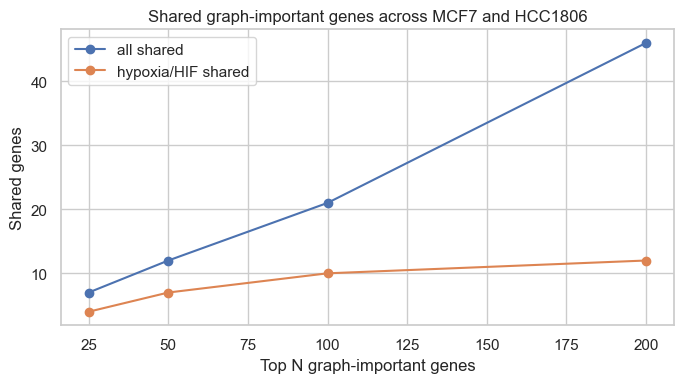

In [ ]:
# Core graph-important genes shared across cell lines

shared_rows = []
shared_gene_rows = []
for n in [25, 50, 100, 200]:
    mcf7 = set(gnn_interpretation["MCF7"].head(n)["gene"].str.upper())
    hcc = set(gnn_interpretation["HCC1806"].head(n)["gene"].str.upper())
    shared = sorted(mcf7 & hcc)
    hyp = sorted(set(shared) & {g.upper() for g in GENE_SETS["PDF_ALL_HYPOXIA_RELATED"]})
    shared_rows.append({
        "top_n": n,
        "shared_graph_important_genes": len(shared),
        "shared_hypoxia_related_genes": len(hyp),
        "examples": ", ".join(hyp[:12])
    })
    for g in shared:
        shared_gene_rows.append({"top_n": n, "gene": g, "hypoxia_related": g in {x.upper() for x in GENE_SETS["PDF_ALL_HYPOXIA_RELATED"]}})

shared_graph_summary = pd.DataFrame(shared_rows)
shared_graph_genes = pd.DataFrame(shared_gene_rows)
display(shared_graph_summary)
shared_graph_summary.to_csv(OUTPUT / "gnn_shared_graph_important_gene_summary.csv", index=False)
shared_graph_genes.to_csv(OUTPUT / "gnn_shared_graph_important_genes.csv", index=False)

plt.figure(figsize=(7,4))
plt.plot(shared_graph_summary["top_n"], shared_graph_summary["shared_graph_important_genes"], marker="o", label="all shared")
plt.plot(shared_graph_summary["top_n"], shared_graph_summary["shared_hypoxia_related_genes"], marker="o", label="hypoxia/HIF shared")
plt.xlabel("Top N graph-important genes")
plt.ylabel("Shared genes")
plt.title("Shared graph-important genes across MCF7 and HCC1806")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
# Cross-cell-line generalization with graph-selected features

def align(X1, X2):
    common = sorted(set(X1.columns) & set(X2.columns))
    return X1[common], X2[common]

rows = []
for feature_set_name, selected_genes in [
    ("top100_graph_MCF7", gnn_interpretation["MCF7"].head(100)["gene"].tolist()),
    ("top100_graph_HCC1806", gnn_interpretation["HCC1806"].head(100)["gene"].tolist()),
    ("PDF_ALL_HYPOXIA_RELATED", list(GENE_SETS["PDF_ALL_HYPOXIA_RELATED"])),
]:
    for train_line, test_line in [("MCF7", "HCC1806"), ("HCC1806", "MCF7")]:
        Xtr = loaded[train_line]["X"]
        Xte = loaded[test_line]["X"]
        genes = sorted(set(selected_genes) & set(Xtr.columns) & set(Xte.columns))
        if len(genes) < 2:
            continue
        ytr = loaded[train_line]["y"]
        yte = loaded[test_line]["y"]
        model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
        model.fit(Xtr[genes], ytr)
        pred = model.predict(Xte[genes])
        proba = model.predict_proba(Xte[genes])[:, 1]
        rows.append({
            "feature_set": feature_set_name,
            "train": train_line,
            "test": test_line,
            "n_genes": len(genes),
            "accuracy": accuracy_score(yte, pred),
            "f1": f1_score(yte, pred),
            "roc_auc": roc_auc_score(yte, proba),
        })

graph_generalization_df = pd.DataFrame(rows)
display(graph_generalization_df)
graph_generalization_df.to_csv(OUTPUT / "gnn_graph_feature_cross_cell_line_generalization.csv", index=False)


,feature_set,train,test,n_genes,accuracy,f1,roc_auc
0,top100_graph_MCF7,MCF7,HCC1806,54,0.736264,0.688312,0.829472
1,top100_graph_MCF7,HCC1806,MCF7,54,0.528000,0.672222,0.562468
2,top100_graph_HCC1806,MCF7,HCC1806,72,0.467033,0.020202,0.857368
3,top100_graph_HCC1806,HCC1806,MCF7,72,0.976000,0.976378,0.999424
4,PDF_ALL_HYPOXIA_RELATED,MCF7,HCC1806,21,0.950549,0.955224,0.984112
5,PDF_ALL_HYPOXIA_RELATED,HCC1806,MCF7,21,0.808000,0.837838,0.994112


# All-dataset extension: models, graphs, gene importance, and cross-dataset generalization

In [33]:
# All-dataset setup and robust file discovery
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.neighbors import kneighbors_graph

SEED = 42
np.random.seed(SEED)

# Works both locally and in the ChatGPT sandbox.
SEARCH_DIRS = []
for candidate in [Path.cwd(), Path('/mnt/data'), globals().get('BASE', None), globals().get('SMART', None), globals().get('DROP', None)]:
    if candidate is not None:
        candidate = Path(candidate)
        if candidate.exists() and candidate not in SEARCH_DIRS:
            SEARCH_DIRS.append(candidate)

OUTPUT_ALL = (globals().get('OUTPUT', None) or Path.cwd() / 'gnn_outputs')
OUTPUT_ALL = Path(OUTPUT_ALL)
OUTPUT_ALL.mkdir(parents=True, exist_ok=True)
print('Searching data in:', SEARCH_DIRS)
print('Output folder:', OUTPUT_ALL)

def find_file(filename):
    for root in SEARCH_DIRS:
        direct = root / filename
        if direct.exists():
            return direct
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    return None

LABELED_TRAIN_FILES = {
    'SmartSeq_MCF7': 'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt',
    'SmartSeq_HCC1806': 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt',
    'DropSeq_MCF7': 'MCF7_Filtered_Normalised_3000_Data_train.txt',
    'DropSeq_HCC1806': 'HCC1806_Filtered_Normalised_3000_Data_train.txt',
}

ANONYMOUS_TEST_FILES = {
    'SmartSeq_MCF7_test_anon': 'MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
    'SmartSeq_HCC1806_test_anon': 'HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt',
    'DropSeq_MCF7_test_anon': 'MCF7_Filtered_Normalised_3000_Data_test_anonim.txt',
    'DropSeq_HCC1806_test_anon': 'HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt',
}

GENE_SETS = {
    'HIF_glycolysis': {'SLC2A1','SLC2A3','HK1','HK2','PFKL','ALDOA','PGAM1','ENO1','LDHA','PDK1','PFKFB3','PGK1'},
    'HIF_angiogenesis': {'VEGFA','VEGFC','ANGPT2','FLT1','NRP1'},
    'HIF_pH_regulation': {'CA9','CA12','SLC9A1'},
    'HIF_survival_apoptosis': {'BNIP3','BNIP3L','BCL2L1'},
    'HIF_erythropoiesis': {'EPO','TFRC'},
    'HIF_ECM_invasion': {'LOX','MMP2','CXCR4'},
    'HIF_cell_cycle': {'CDKN1A','CCND1'},
    'compact_hypoxia_signature': {
        'DDIT4','NDRG1','BNIP3','BNIP3L','CA9','CA12','VEGFA','ADM','ANGPTL4','EGLN1','EGLN3',
        'ENO1','LDHA','PDK1','PFKFB3','HK2','SLC2A1','SLC2A3','PGK1','ALDOA','LOX','MMP2','CXCR4','TFRC'
    },
}
GENE_SETS['all_hypoxia_related'] = set().union(*GENE_SETS.values())
HYPOXIA_UPPER = {g.upper() for g in GENE_SETS['all_hypoxia_related']}

def load_expr_matrix(path):
    df = pd.read_csv(path, sep=r'\s+', engine='python', index_col=0)
    df.index = df.index.astype(str).str.replace('"', '', regex=False)
    df.columns = df.columns.astype(str).str.replace('"', '', regex=False)
    return df.apply(pd.to_numeric, errors='coerce').fillna(0)

def labels_from_columns(columns):
    y = []
    for col in columns:
        low = str(col).lower()
        if 'hyp' in low:
            y.append(1)
        elif 'norm' in low:
            y.append(0)
        else:
            y.append(np.nan)
    return np.array(y, dtype=float)

def expr_to_xy(expr):
    y = labels_from_columns(expr.columns)
    keep = ~np.isnan(y)
    X = expr.loc[:, keep].T.copy()
    y = y[keep].astype(int)
    X = X.loc[:, X.var(axis=0) > 0]
    return X, y

loaded_all = {}
missing_labelled_files = []
for dataset_name, filename in LABELED_TRAIN_FILES.items():
    path = find_file(filename)
    if path is None:
        missing_labelled_files.append(filename)
        print(f'SKIP {dataset_name}: missing labelled training file {filename}')
        continue
    expr = load_expr_matrix(path)
    X, y = expr_to_xy(expr)
    if len(np.unique(y)) < 2:
        print(f'SKIP {dataset_name}: labels could not be inferred from column names')
        continue
    loaded_all[dataset_name] = {'path': path, 'expr': expr, 'X': X, 'y': y}
    print(f'{dataset_name}: X={X.shape}, hypoxia={int(y.sum())}, normoxia={int((1-y).sum())}')

anonymous_tests = {}
for dataset_name, filename in ANONYMOUS_TEST_FILES.items():
    path = find_file(filename)
    if path is not None:
        anonymous_tests[dataset_name] = {'path': path, 'expr': load_expr_matrix(path)}

print('\nLoaded labelled datasets:', list(loaded_all))
print('Anonymous test files found:', list(anonymous_tests))
if missing_labelled_files:
    print('Missing labelled training files:', missing_labelled_files)

Searching data in: [WindowsPath('c:/Users/hugoo/OneDrive/Desktop/ai-lab-report/notebooks'), WindowsPath('C:/Users/hugoo/OneDrive/Desktop/ai-lab-report/data'), WindowsPath('C:/Users/hugoo/OneDrive/Desktop/ai-lab-report/data/SmartSeq'), WindowsPath('C:/Users/hugoo/OneDrive/Desktop/ai-lab-report/data/DropSeq')]
Output folder: C:\Users\hugoo\OneDrive\Desktop\ai-lab-report\gnn_outputs
SmartSeq_MCF7: X=(250, 3000), hypoxia=124, normoxia=126
SmartSeq_HCC1806: X=(182, 3000), hypoxia=97, normoxia=85
DropSeq_MCF7: X=(21626, 3000), hypoxia=8921, normoxia=12705
DropSeq_HCC1806: X=(14682, 3000), hypoxia=8899, normoxia=5783

Loaded labelled datasets: ['SmartSeq_MCF7', 'SmartSeq_HCC1806', 'DropSeq_MCF7', 'DropSeq_HCC1806']
Anonymous test files found: ['SmartSeq_MCF7_test_anon', 'SmartSeq_HCC1806_test_anon', 'DropSeq_MCF7_test_anon', 'DropSeq_HCC1806_test_anon']


## A. PCA plots and kNN cell-graph visualisations for every labelled dataset

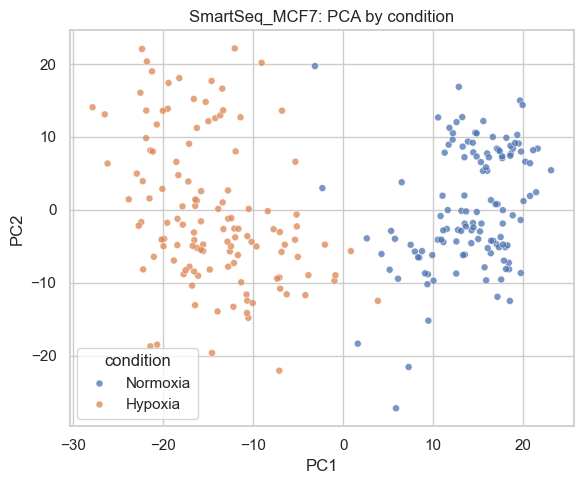

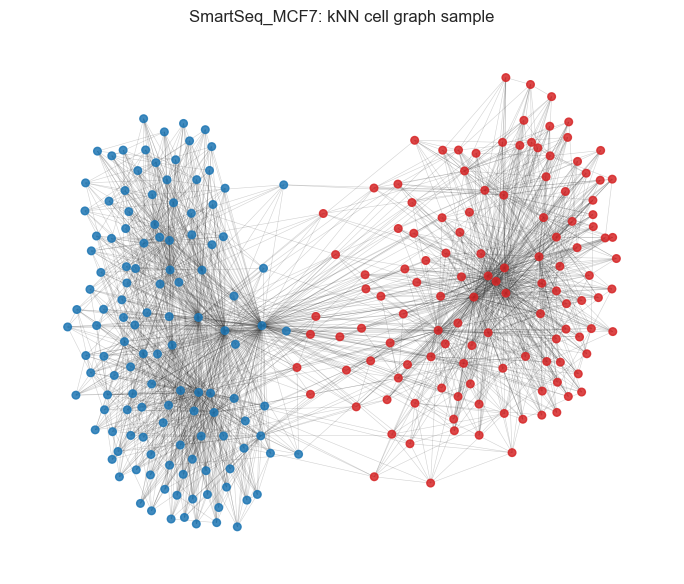

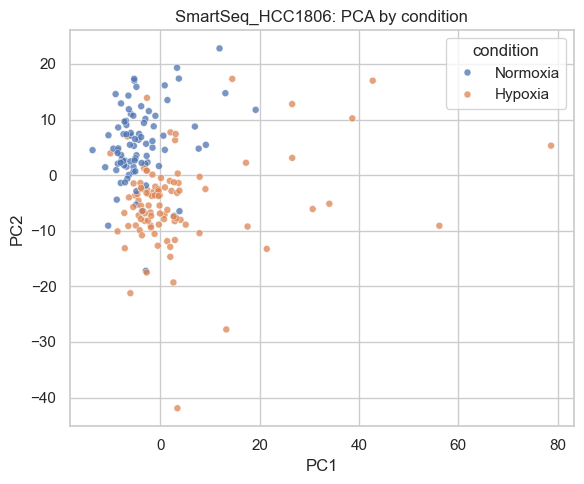

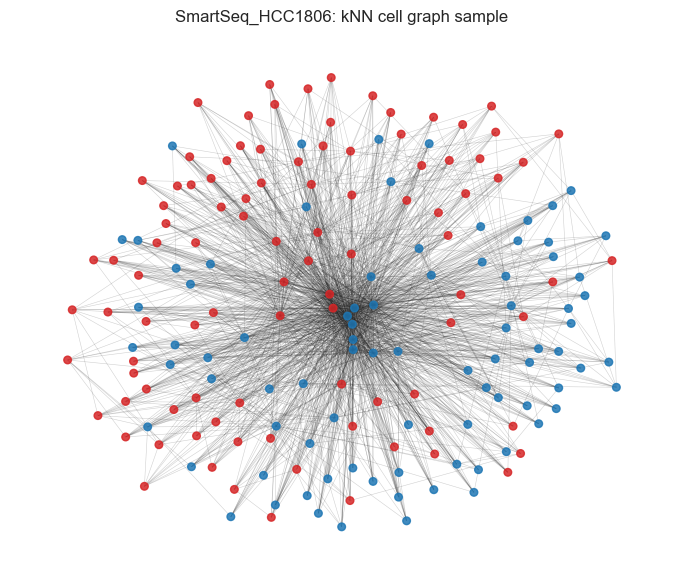

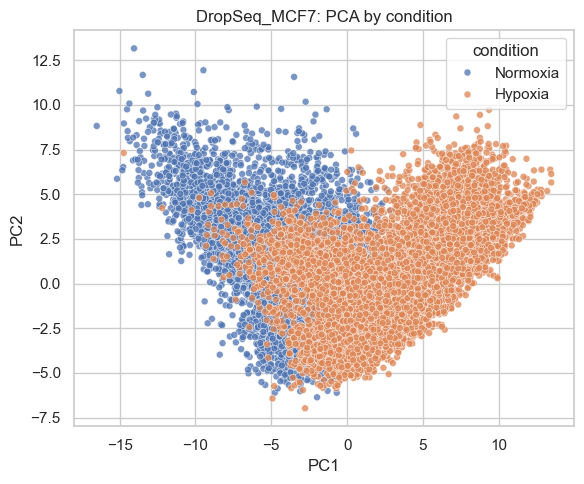

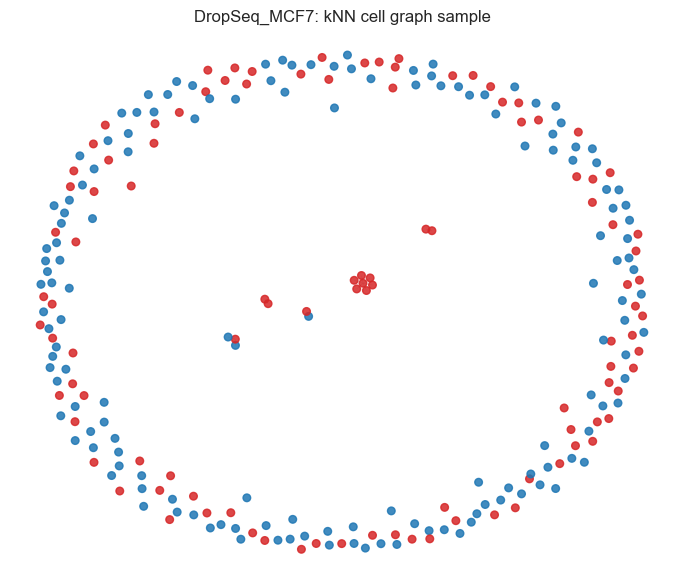

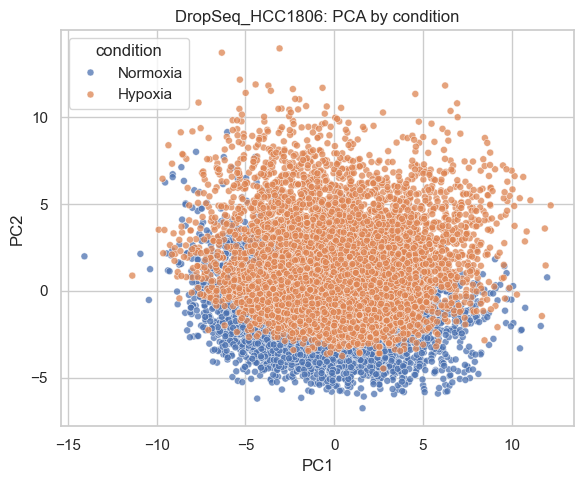

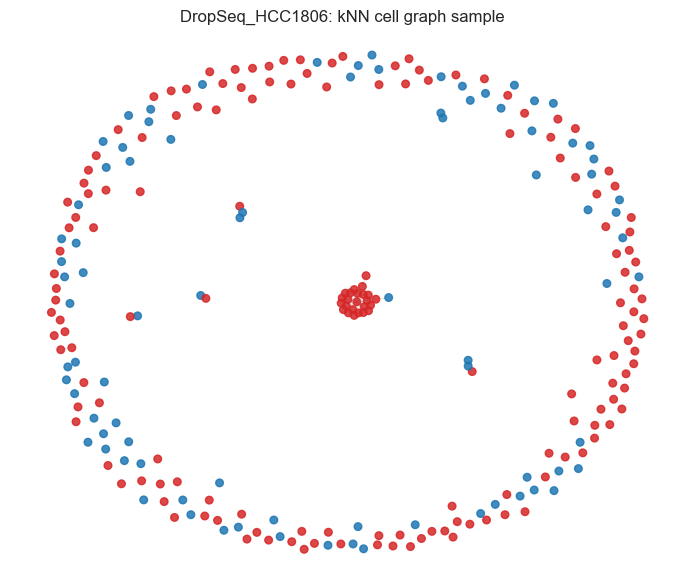

In [34]:
def plot_pca_by_condition(name, X, y):
    X_scaled = StandardScaler().fit_transform(X)
    pcs = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)
    df = pd.DataFrame({
        'PC1': pcs[:, 0],
        'PC2': pcs[:, 1],
        'condition': np.where(y == 1, 'Hypoxia', 'Normoxia'),
        'dataset': name,
    })
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='condition', s=25, alpha=0.75)
    plt.title(f'{name}: PCA by condition')
    plt.tight_layout()
    plt.savefig(OUTPUT_ALL / f'{name}_PCA_condition.png', dpi=160)
    plt.show()
    return df

def plot_knn_cell_graph(name, X, y, k=10, max_nodes=250):
    X_scaled = StandardScaler().fit_transform(X)
    adjacency = kneighbors_graph(X_scaled, n_neighbors=min(k, len(X)-1), mode='connectivity', include_self=False)
    adjacency = adjacency.maximum(adjacency.T)
    selected = np.arange(len(X))
    if len(selected) > max_nodes:
        selected = np.random.default_rng(SEED).choice(selected, size=max_nodes, replace=False)
    selected_set = set(selected)
    rows, cols = adjacency.nonzero()
    G = nx.Graph()
    G.add_nodes_from(selected)
    for a, b in zip(rows, cols):
        if a in selected_set and b in selected_set:
            G.add_edge(a, b)
    colors = ['tab:red' if y[i] == 1 else 'tab:blue' for i in G.nodes()]
    plt.figure(figsize=(7, 6))
    pos = nx.spring_layout(G, seed=SEED)
    nx.draw_networkx_nodes(G, pos, node_size=30, node_color=colors, alpha=0.85)
    nx.draw_networkx_edges(G, pos, width=0.4, alpha=0.2)
    plt.title(f'{name}: kNN cell graph sample')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_ALL / f'{name}_kNN_cell_graph.png', dpi=160)
    plt.show()
    return adjacency

pca_frames = []
cell_adjacencies = {}
for name, d in loaded_all.items():
    pca_frames.append(plot_pca_by_condition(name, d['X'], d['y']))
    cell_adjacencies[name] = plot_knn_cell_graph(name, d['X'], d['y'], k=10)

all_pca_coordinates = pd.concat(pca_frames, ignore_index=True) if pca_frames else pd.DataFrame()
all_pca_coordinates.to_csv(OUTPUT_ALL / 'all_labelled_datasets_PCA_coordinates.csv', index=False)

## B. Supervised prediction models for every labelled dataset

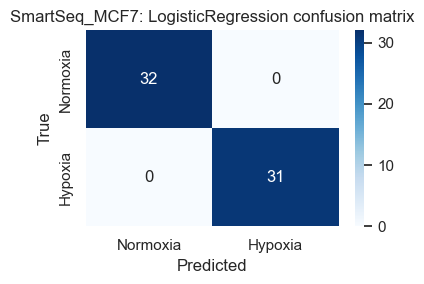

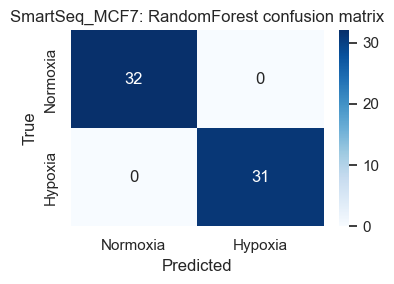

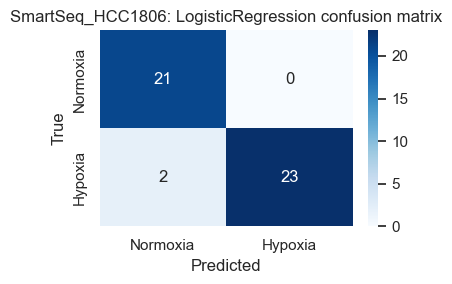

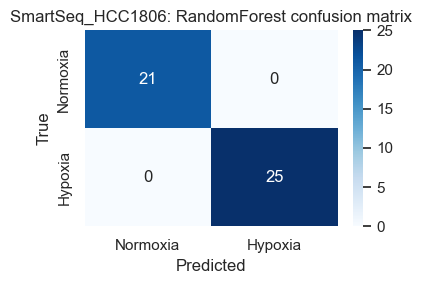

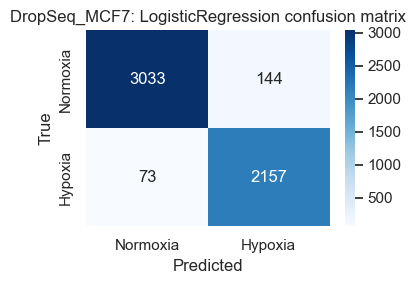

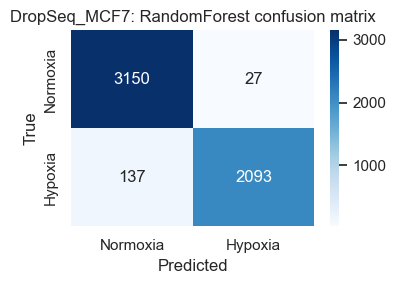

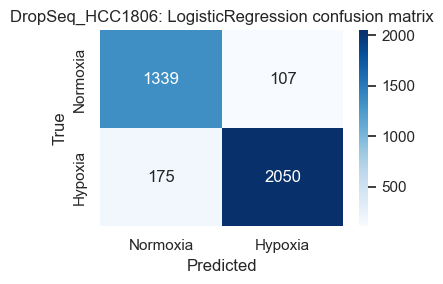

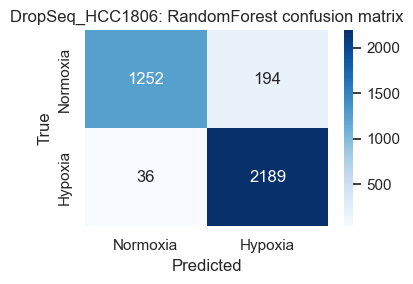

,dataset,model,accuracy,f1,roc_auc,n_train,n_test,n_genes
0,SmartSeq_MCF7,LogisticRegression,1.000000,1.000000,1.000000,187,63,3000
1,SmartSeq_MCF7,RandomForest,1.000000,1.000000,1.000000,187,63,3000
2,SmartSeq_HCC1806,LogisticRegression,0.956522,0.958333,1.000000,136,46,3000
3,SmartSeq_HCC1806,RandomForest,1.000000,1.000000,1.000000,136,46,3000
4,DropSeq_MCF7,LogisticRegression,0.959867,0.952108,0.993577,16219,5407,3000
5,DropSeq_MCF7,RandomForest,0.969669,0.962299,0.994424,16219,5407,3000
6,DropSeq_HCC1806,LogisticRegression,0.923182,0.935646,0.974568,11011,3671,3000
7,DropSeq_HCC1806,RandomForest,0.937347,0.950087,0.989313,11011,3671,3000


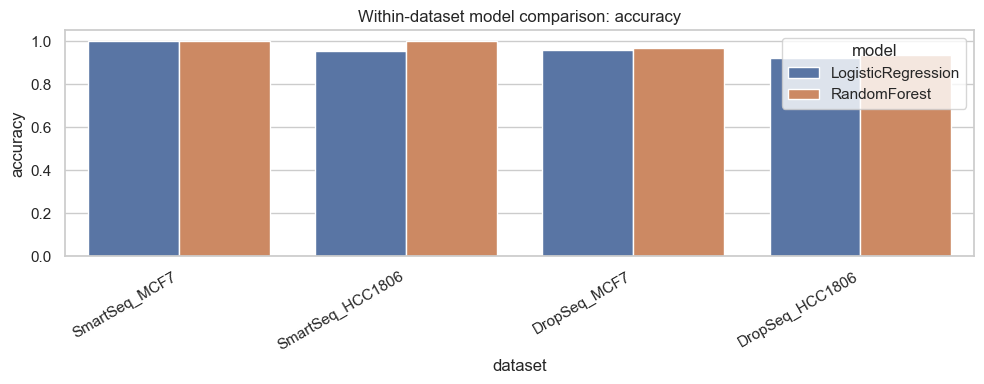

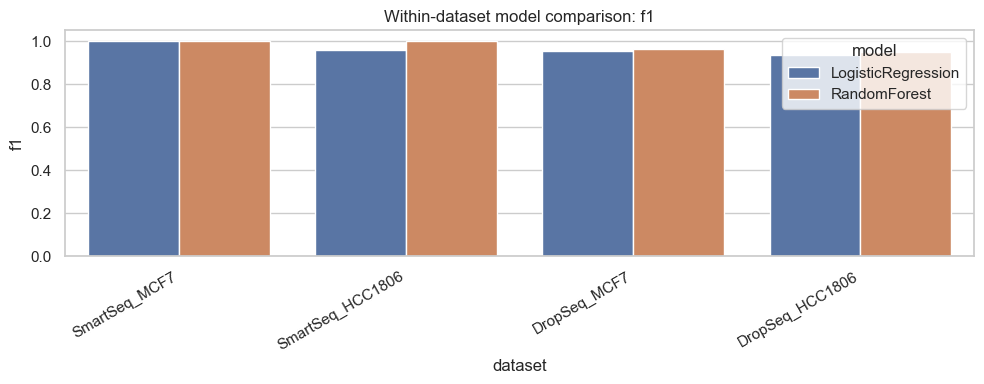

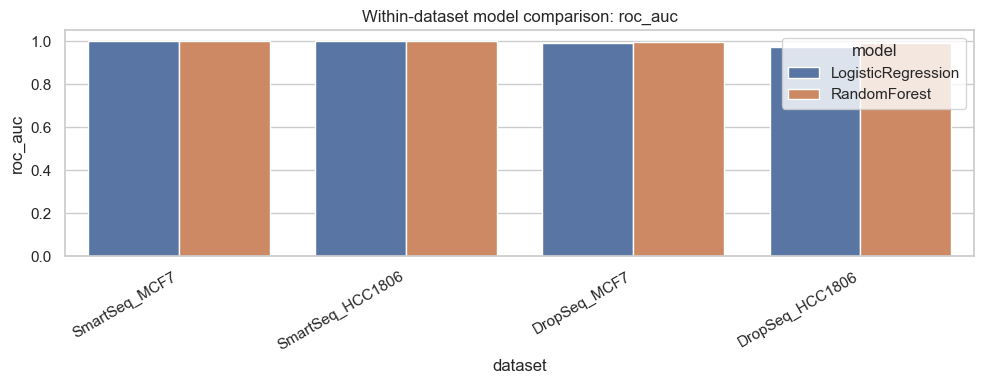

In [35]:
def train_within_dataset_models(name, X, y, test_size=0.25):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=SEED, stratify=y
    )
    models = {
        'LogisticRegression': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED)
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=150, random_state=SEED, class_weight='balanced', n_jobs=-1
        ),
    }
    rows = []
    gene_importance = None
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]
        rows.append({
            'dataset': name,
            'model': model_name,
            'accuracy': accuracy_score(y_test, pred),
            'f1': f1_score(y_test, pred),
            'roc_auc': roc_auc_score(y_test, proba),
            'n_train': len(y_train),
            'n_test': len(y_test),
            'n_genes': X.shape[1],
        })
        cm = confusion_matrix(y_test, pred)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normoxia','Hypoxia'], yticklabels=['Normoxia','Hypoxia'])
        plt.title(f'{name}: {model_name} confusion matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(OUTPUT_ALL / f'{name}_{model_name}_confusion_matrix.png', dpi=160)
        plt.show()
        if model_name == 'RandomForest':
            gene_importance = pd.DataFrame({
                'gene': X.columns,
                'importance': model.feature_importances_,
            }).sort_values('importance', ascending=False)
            gene_importance['hypoxia_related'] = gene_importance['gene'].str.upper().isin(HYPOXIA_UPPER)
            gene_importance.to_csv(OUTPUT_ALL / f'{name}_RandomForest_gene_importance.csv', index=False)
    return pd.DataFrame(rows), gene_importance

within_rows = []
rf_importances = {}
for name, d in loaded_all.items():
    metrics, imp = train_within_dataset_models(name, d['X'], d['y'])
    within_rows.append(metrics)
    rf_importances[name] = imp

within_dataset_metrics = pd.concat(within_rows, ignore_index=True) if within_rows else pd.DataFrame()
within_dataset_metrics.to_csv(OUTPUT_ALL / 'within_dataset_model_metrics_all_labelled_datasets.csv', index=False)
display(within_dataset_metrics)

for metric in ['accuracy', 'f1', 'roc_auc']:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=within_dataset_metrics, x='dataset', y=metric, hue='model')
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha='right')
    plt.title(f'Within-dataset model comparison: {metric}')
    plt.tight_layout()
    plt.savefig(OUTPUT_ALL / f'within_dataset_{metric}_barplot.png', dpi=160)
    plt.show()

## C. Cross-dataset generalization: train on one dataset, test on another

,train_dataset,test_dataset,n_common_genes,accuracy,f1,roc_auc
0,SmartSeq_MCF7,SmartSeq_MCF7,3000,1.000000,1.000000,1.000000
1,SmartSeq_MCF7,SmartSeq_HCC1806,1208,0.554945,0.372093,0.741055
2,SmartSeq_MCF7,DropSeq_MCF7,496,0.412513,0.584084,0.582604
3,SmartSeq_MCF7,DropSeq_HCC1806,547,0.606116,0.754760,0.630249
4,SmartSeq_HCC1806,SmartSeq_MCF7,1208,0.600000,0.705882,0.887225
5,SmartSeq_HCC1806,SmartSeq_HCC1806,3000,1.000000,1.000000,1.000000
6,SmartSeq_HCC1806,DropSeq_MCF7,445,0.587487,0.000000,0.561891
7,SmartSeq_HCC1806,DropSeq_HCC1806,516,0.393884,0.000000,0.708270
8,DropSeq_MCF7,SmartSeq_MCF7,496,0.984000,0.984127,0.984127
9,DropSeq_MCF7,SmartSeq_HCC1806,445,0.560440,0.344262,0.589630


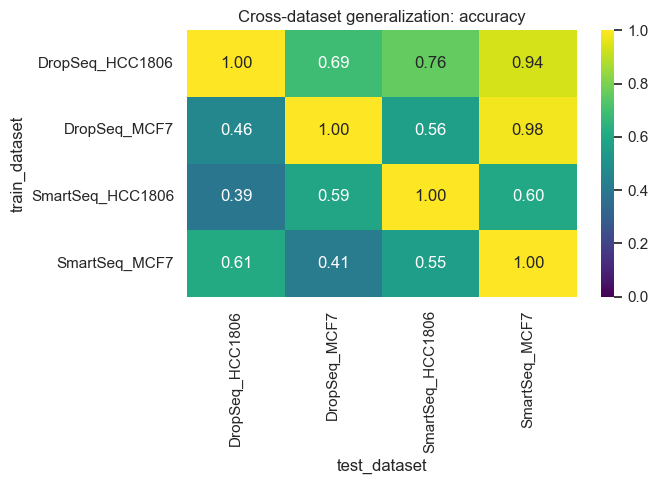

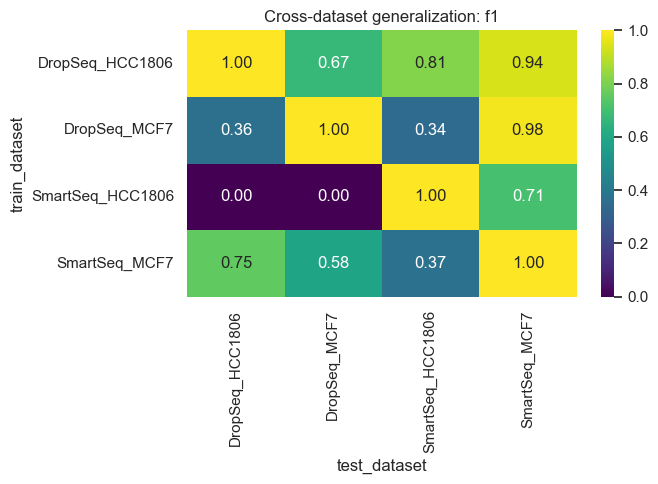

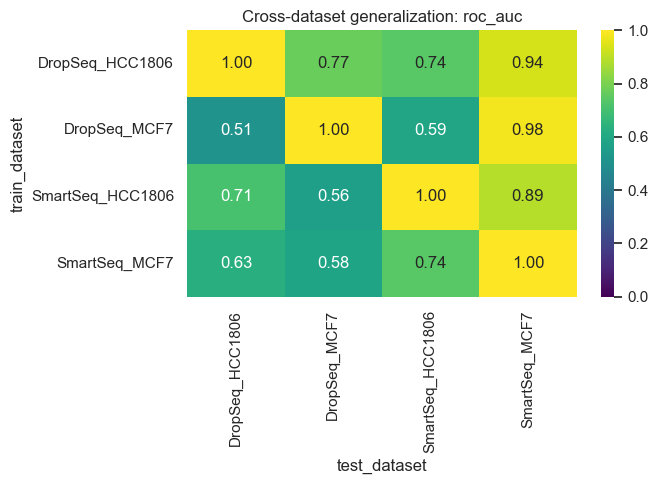

In [36]:
def cross_dataset_generalization(loaded_dict):
    rows = []
    for train_name, train_d in loaded_dict.items():
        for test_name, test_d in loaded_dict.items():
            common_genes = sorted(set(train_d['X'].columns) & set(test_d['X'].columns))
            if len(common_genes) < 2:
                continue
            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED)
            )
            model.fit(train_d['X'][common_genes], train_d['y'])
            pred = model.predict(test_d['X'][common_genes])
            proba = model.predict_proba(test_d['X'][common_genes])[:, 1]
            rows.append({
                'train_dataset': train_name,
                'test_dataset': test_name,
                'n_common_genes': len(common_genes),
                'accuracy': accuracy_score(test_d['y'], pred),
                'f1': f1_score(test_d['y'], pred),
                'roc_auc': roc_auc_score(test_d['y'], proba),
            })
    return pd.DataFrame(rows)

cross_dataset_metrics = cross_dataset_generalization(loaded_all)
cross_dataset_metrics.to_csv(OUTPUT_ALL / 'cross_dataset_generalization_logistic_regression.csv', index=False)
display(cross_dataset_metrics)

for metric in ['accuracy', 'f1', 'roc_auc']:
    matrix = cross_dataset_metrics.pivot(index='train_dataset', columns='test_dataset', values=metric)
    plt.figure(figsize=(7, 5))
    sns.heatmap(matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis')
    plt.title(f'Cross-dataset generalization: {metric}')
    plt.tight_layout()
    plt.savefig(OUTPUT_ALL / f'cross_dataset_{metric}_heatmap.png', dpi=160)
    plt.show()

## D. Graph-weighted gene importance for every labelled dataset

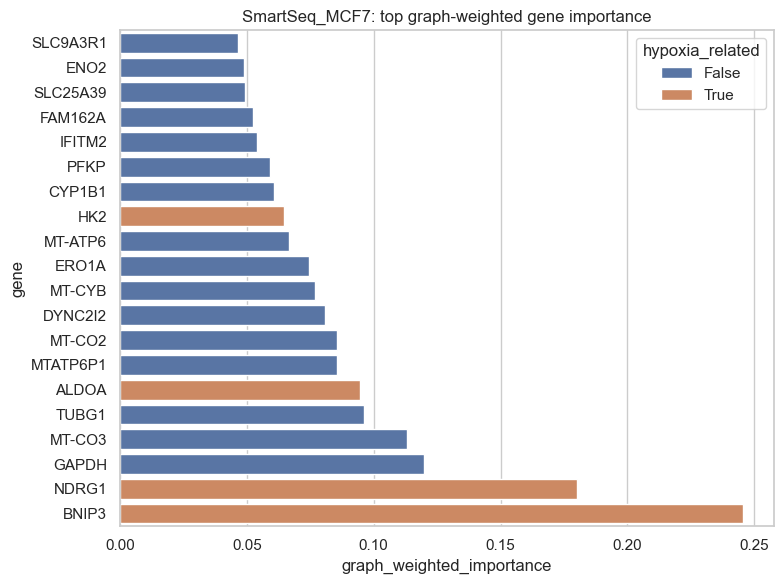


SmartSeq_MCF7: top graph-important hypoxia/HIF genes


,gene,node_importance,coexpression_degree,graph_weighted_importance
40,BNIP3,7.227244e-02,10,2.455742e-01
85,NDRG1,5.844282e-02,7,1.799713e-01
2,ALDOA,3.204496e-02,6,9.440157e-02
26,HK2,3.805842e-02,1,6.443850e-02
9,PGK1,1.910187e-02,3,4.558270e-02
21,PFKFB3,1.153584e-02,3,2.752791e-02
216,BNIP3L,1.303113e-02,2,2.734730e-02
71,VEGFA,1.157551e-02,2,2.429250e-02
13,DDIT4,1.038994e-02,0,1.038994e-02
14,LDHA,2.429336e-03,8,7.767132e-03


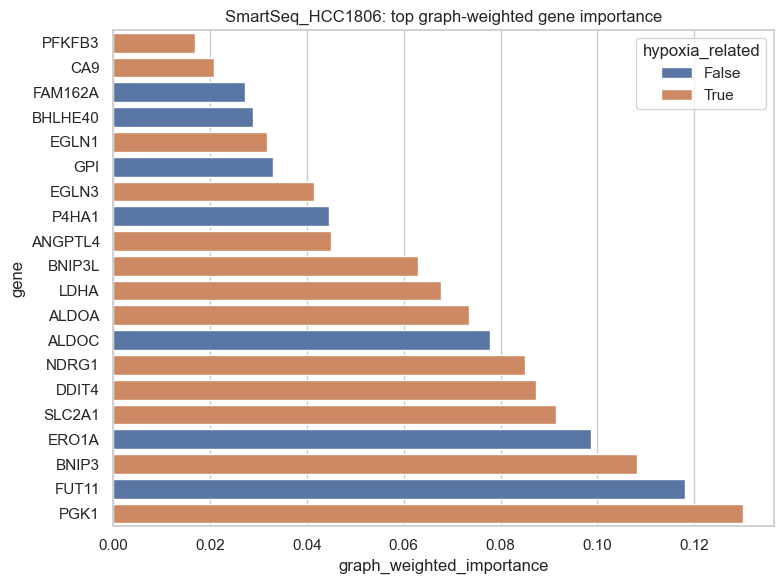


SmartSeq_HCC1806: top graph-important hypoxia/HIF genes


,gene,node_importance,coexpression_degree,graph_weighted_importance
25,PGK1,3.934437e-02,9,1.299381e-01
146,BNIP3,4.142893e-02,4,1.081062e-01
56,SLC2A1,3.831235e-02,3,9.142454e-02
11,DDIT4,4.161306e-02,2,8.732968e-02
150,NDRG1,5.021029e-02,1,8.501341e-02
14,ALDOA,2.813546e-02,4,7.341775e-02
2,LDHA,2.424362e-02,5,6.768236e-02
401,BNIP3L,2.635042e-02,3,6.287986e-02
31,ANGPTL4,4.504823e-02,0,4.504823e-02
314,EGLN3,4.142132e-02,0,4.142132e-02


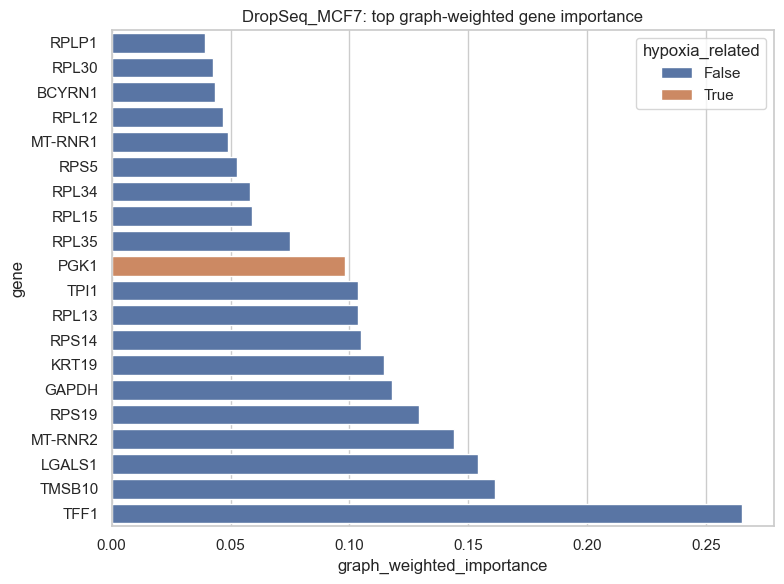


DropSeq_MCF7: top graph-important hypoxia/HIF genes


,gene,node_importance,coexpression_degree,graph_weighted_importance
86,PGK1,0.037619,4,0.098163
41,ENO1,0.022922,1,0.038811
485,CDKN1A,0.000218,1,0.000370


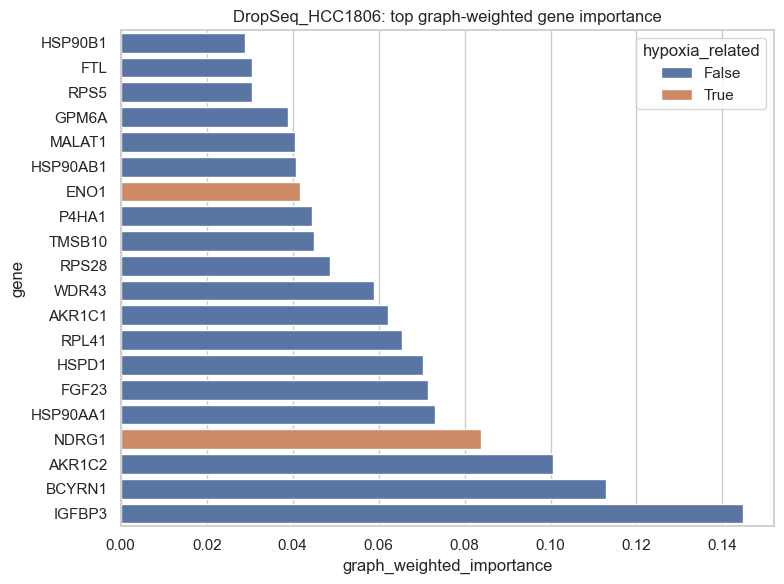


DropSeq_HCC1806: top graph-important hypoxia/HIF genes


,gene,node_importance,coexpression_degree,graph_weighted_importance
103,NDRG1,0.049505,1,0.083819
5,ENO1,0.010568,18,0.041684
34,LDHA,0.023059,0,0.023059
195,BNIP3,0.010398,0,0.010398
141,PGK1,0.007699,0,0.007699
324,EGLN3,0.004231,0,0.004231
294,BNIP3L,0.003018,0,0.003018
403,DDIT4,0.001049,0,0.001049
375,SLC2A1,0.000911,0,0.000911
422,PGAM1,0.000594,0,0.000594


In [37]:
def graph_weighted_gene_importance(name, X, y, top_variable=500, corr_quantile=0.995):
    # Use most variable genes to keep the co-expression graph fast and interpretable.
    genes = X.var(axis=0).sort_values(ascending=False).head(min(top_variable, X.shape[1])).index.tolist()
    Xs = X[genes]

    rf = RandomForestClassifier(n_estimators=150, random_state=SEED, class_weight='balanced', n_jobs=-1)
    rf.fit(Xs, y)
    imp = pd.DataFrame({'gene': genes, 'node_importance': rf.feature_importances_})

    X_scaled = StandardScaler().fit_transform(Xs)
    corr = np.corrcoef(X_scaled.T)
    np.fill_diagonal(corr, 0)
    abs_corr = np.abs(corr)
    threshold = np.quantile(abs_corr, corr_quantile)
    adjacency = abs_corr >= threshold

    imp['coexpression_degree'] = adjacency.sum(axis=0)
    imp['graph_weighted_importance'] = imp['node_importance'] * (1 + np.log1p(imp['coexpression_degree']))
    imp['hypoxia_related'] = imp['gene'].str.upper().isin(HYPOXIA_UPPER)
    for set_name, geneset in GENE_SETS.items():
        imp[set_name] = imp['gene'].str.upper().isin({g.upper() for g in geneset})
    imp = imp.sort_values('graph_weighted_importance', ascending=False)
    imp.to_csv(OUTPUT_ALL / f'{name}_graph_weighted_gene_importance.csv', index=False)

    top = imp.head(20).iloc[::-1]
    plt.figure(figsize=(8, 6))
    sns.barplot(data=top, y='gene', x='graph_weighted_importance', hue='hypoxia_related', dodge=False)
    plt.title(f'{name}: top graph-weighted gene importance')
    plt.tight_layout()
    plt.savefig(OUTPUT_ALL / f'{name}_top20_graph_weighted_gene_importance.png', dpi=160)
    plt.show()

    print(f'\n{name}: top graph-important hypoxia/HIF genes')
    display(imp.query('hypoxia_related').head(20)[['gene', 'node_importance', 'coexpression_degree', 'graph_weighted_importance']])
    return imp, adjacency

graph_importances = {}
gene_graph_adjacencies = {}
for name, d in loaded_all.items():
    imp, adj = graph_weighted_gene_importance(name, d['X'], d['y'], top_variable=500)
    graph_importances[name] = imp
    gene_graph_adjacencies[name] = adj

## E. Shared/core hypoxia genes across datasets

,top_n,shared_graph_important_genes_all_available_labelled_datasets,shared_hypoxia_related_genes,hypoxia_examples
0,25,0,0,
1,50,0,0,
2,100,1,1,PGK1
3,200,5,1,PGK1


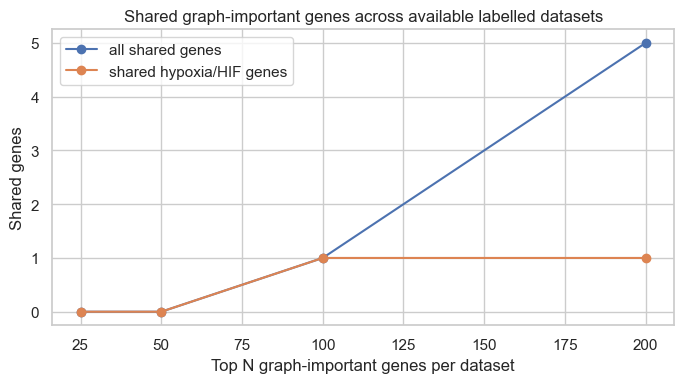

In [38]:
shared_rows = []
shared_gene_rows = []
for top_n in [25, 50, 100, 200]:
    top_sets = [set(imp.head(top_n)['gene'].str.upper()) for imp in graph_importances.values()]
    shared = sorted(set.intersection(*top_sets)) if top_sets else []
    shared_hypoxia = sorted(set(shared) & HYPOXIA_UPPER)
    shared_rows.append({
        'top_n': top_n,
        'shared_graph_important_genes_all_available_labelled_datasets': len(shared),
        'shared_hypoxia_related_genes': len(shared_hypoxia),
        'hypoxia_examples': ', '.join(shared_hypoxia[:15]),
    })
    for gene in shared:
        shared_gene_rows.append({
            'top_n': top_n,
            'gene': gene,
            'hypoxia_related': gene in HYPOXIA_UPPER,
        })

shared_core_summary = pd.DataFrame(shared_rows)
shared_core_genes = pd.DataFrame(shared_gene_rows)
shared_core_summary.to_csv(OUTPUT_ALL / 'shared_core_graph_important_genes_summary.csv', index=False)
shared_core_genes.to_csv(OUTPUT_ALL / 'shared_core_graph_important_genes_long.csv', index=False)
display(shared_core_summary)

plt.figure(figsize=(7, 4))
plt.plot(shared_core_summary['top_n'], shared_core_summary['shared_graph_important_genes_all_available_labelled_datasets'], marker='o', label='all shared genes')
plt.plot(shared_core_summary['top_n'], shared_core_summary['shared_hypoxia_related_genes'], marker='o', label='shared hypoxia/HIF genes')
plt.xlabel('Top N graph-important genes per dataset')
plt.ylabel('Shared genes')
plt.title('Shared graph-important genes across available labelled datasets')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_ALL / 'shared_core_graph_important_genes_plot.png', dpi=160)
plt.show()

## F. Optional: predict anonymous test files with a combined labelled model

In [39]:
# Anonymous test files do not contain ground-truth labels, so this only creates predictions.
# It is not an evaluation result.
if anonymous_tests and loaded_all:
    common_train_genes = sorted(set.intersection(*[set(d['X'].columns) for d in loaded_all.values()]))
    X_combined = pd.concat([d['X'][common_train_genes] for d in loaded_all.values()], axis=0)
    y_combined = np.concatenate([d['y'] for d in loaded_all.values()])
    combined_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED)
    )
    combined_model.fit(X_combined, y_combined)

    prediction_rows = []
    for test_name, test_d in anonymous_tests.items():
        expr_test = test_d['expr']
        X_test = expr_test.T.copy()
        genes = sorted(set(common_train_genes) & set(X_test.columns))
        if len(genes) < 2:
            continue
        pred = combined_model.predict(X_test[genes])
        proba = combined_model.predict_proba(X_test[genes])[:, 1]
        pred_df = pd.DataFrame({
            'sample': X_test.index,
            'predicted_condition': np.where(pred == 1, 'Hypoxia', 'Normoxia'),
            'hypoxia_probability': proba,
            'n_genes_used': len(genes),
            'test_dataset': test_name,
        })
        pred_df.to_csv(OUTPUT_ALL / f'{test_name}_anonymous_predictions.csv', index=False)
        prediction_rows.append(pred_df)
    anonymous_predictions = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()
    display(anonymous_predictions.head())
else:
    print('No anonymous tests found, or no labelled training datasets loaded.')

,sample,predicted_condition,hypoxia_probability,n_genes_used,test_dataset
0,1,Hypoxia,1.000000e+00,70,SmartSeq_MCF7_test_anon
1,2,Hypoxia,1.000000e+00,70,SmartSeq_MCF7_test_anon
2,3,Normoxia,1.988559e-68,70,SmartSeq_MCF7_test_anon
3,4,Normoxia,3.719028e-33,70,SmartSeq_MCF7_test_anon
4,5,Normoxia,2.617691e-47,70,SmartSeq_MCF7_test_anon


## GNN interpretation

This GNN extension turns the graph analysis into a biological argument:

- genes with high graph-weighted importance are influential both as predictors and as connected nodes in the co-expression graph;
- overlap with HIF/hypoxia signatures supports that the graph model is detecting biologically meaningful hypoxia structure;
- the shared graph-important genes across MCF7 and HCC1806 can be described as a candidate graph-derived core hypoxia signature;
- cross-cell-line testing with graph-selected genes checks whether these nodes generalize beyond one cell line.